In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as po
import plotly.express as px


In [49]:
df = pd.read_csv('/content/gym_members_exercise_tracking.csv')

### BASIC INSPECTION

In [50]:
df.sample(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
563,18,Female,65.3,1.55,184,161,59,1.42,1143.0,Yoga,28.5,2.2,3,2,27.18
821,42,Male,79.3,1.93,181,147,50,1.22,888.0,Cardio,27.3,3.3,2,1,21.29
636,26,Male,47.7,1.77,198,120,69,1.15,759.0,Strength,24.8,2.7,3,2,15.23
475,27,Male,89.3,1.64,192,162,64,1.82,1622.0,HIIT,12.1,3.5,4,3,33.20
530,38,Male,88.4,1.79,182,138,68,1.74,1321.0,Yoga,12.5,3.5,5,3,27.59


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.nunique()

,0
Age,42
Gender,2
Weight (kg),532
Height (m),51
Max_BPM,40
Avg_BPM,50
Resting_BPM,25
Session_Duration (hours),147
Calories_Burned,621
Workout_Type,4


In [54]:
df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


In [55]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [56]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

### EDA

In [57]:
cat_col = df.select_dtypes(include='object').columns
num_col = df.select_dtypes(include='number').columns

print(f"Categorical Columns: {cat_col}")
print(f"Numerical Columns: {num_col}")

Categorical Columns: Index(['Gender', 'Workout_Type'], dtype='object')
Numerical Columns: Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI'],
      dtype='object')


In [58]:
cat_columns = df[['Gender', 'Workout_Type','Workout_Frequency (days/week)','Experience_Level']]
def univariate_analysis(cols):
  print("Distribution of", cols)
  print("_"*50)
  colors = [
        '#FFD700', '#FF6347', '#40E0D0', '#FF69B4', '#7FFFD4',
        '#FFA500', '#00FA9A', '#FF4500', '#4682B4', '#DA70D6',
        '#FFB6C1', '#FF1493', '#FF8C00', '#98FB98', '#9370DB',
        '#32CD32', '#00CED1', '#1E90FF', '#FFFF00', '#7CFC00'
    ]

  value_counts = cat_columns[cols].value_counts()

  #Create a bar plot
  fig = px.bar(
                x=value_counts.index,
                y=value_counts.values,
                title = f"Distibution of {cols}",
                labels = {'x':'Categories','y':'Count'},
                color_discrete_sequence=colors)

  fig.update_layout( plot_bgcolor='#000000',
        paper_bgcolor='#000000',
        font=dict(color='white', size=12),
        title_font=dict(size=30),
        legend_font=dict(color='white', size=12),
        width=500,
        height=400
        )
  fig.show()

  #Create a pie chart
  fig = px.pie(
      values = value_counts.values,
      names=value_counts.index,
      labels={'names': 'Categories', 'values': 'Percentage'},
      hole=0.5,
      color_discrete_sequence=colors
    )
  fig.add_annotation(
      x=0.5, y=0.5,
        text=f'{cols}',
        font=dict(size=18, color='white'),
        showarrow=False
    )
  fig.update_layout(
        plot_bgcolor='#000000',
        paper_bgcolor='#000000',
        font=dict(color='white', size=12),
        title_font=dict(size=30),
        legend=dict(x=0.9, y=0.5),
        legend_font=dict(color='white', size=12),
        width=500,  # Adjusted width
        height=400  # Adjusted height
    )
  fig.show()
  print("       ")

for x in cat_columns:
    univariate_analysis(x)

Distribution of Gender
__________________________________________________


       
Distribution of Workout_Type
__________________________________________________


       
Distribution of Workout_Frequency (days/week)
__________________________________________________


       
Distribution of Experience_Level
__________________________________________________


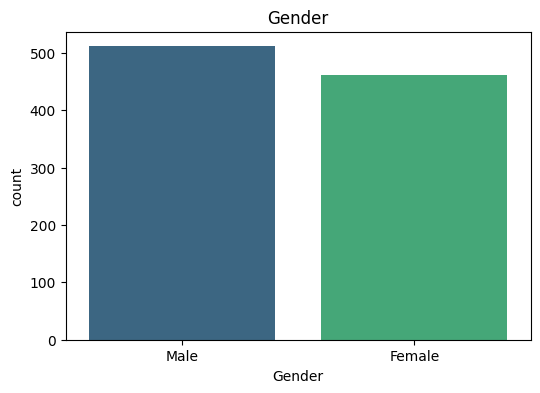

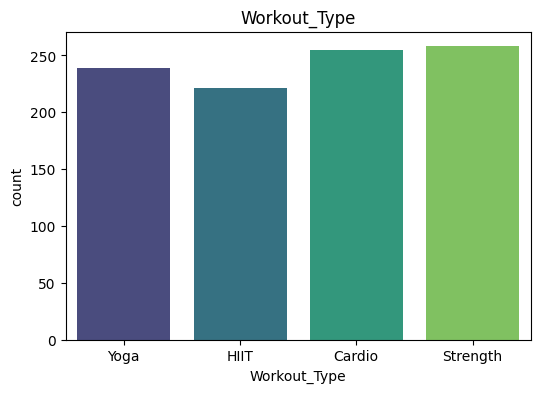

In [59]:
for col in cat_col:
  plt.figure(figsize=(6,4))
  sns.countplot(x=df[col],palette='viridis')
  plt.title(col)
  plt.show()

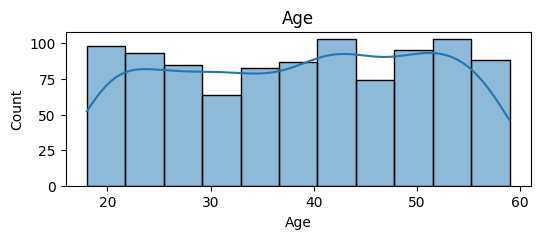

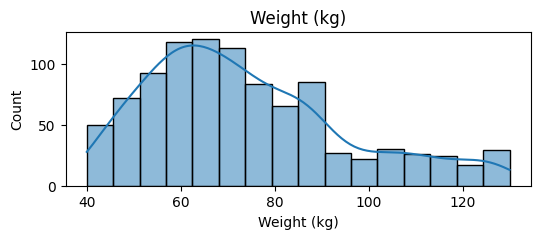

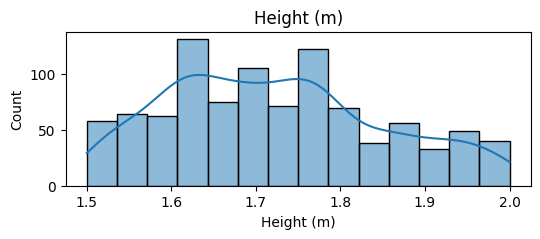

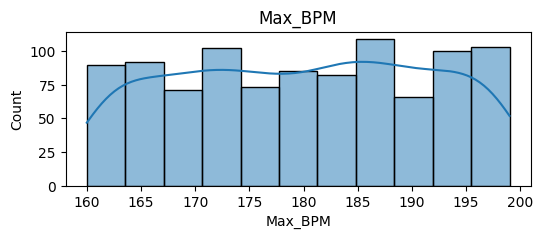

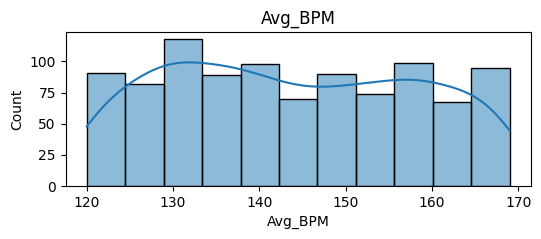

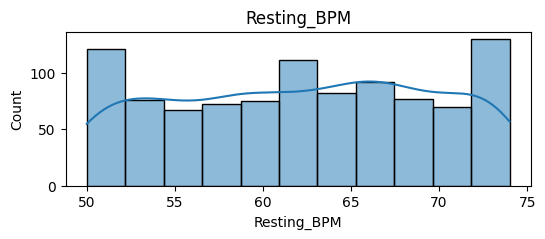

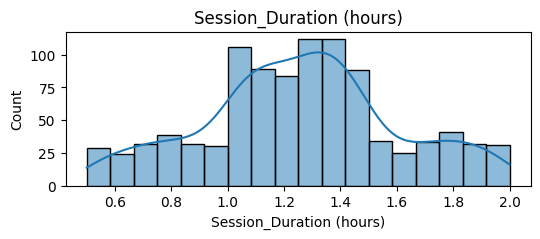

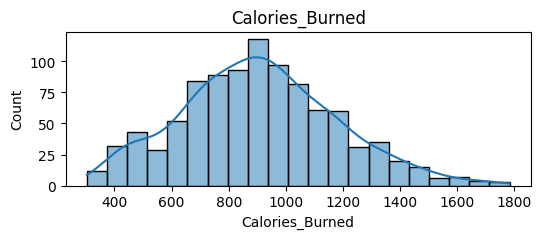

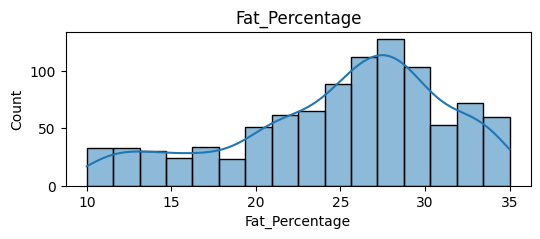

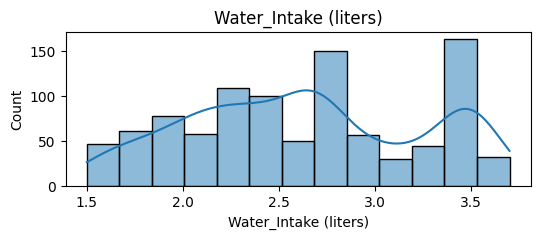

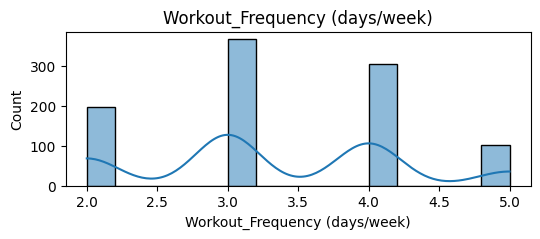

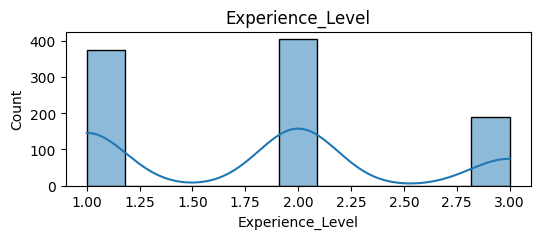

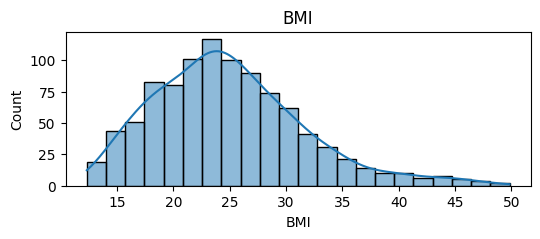

In [60]:
for col in num_col:
  plt.figure(figsize=(6,2))
  sns.histplot(x=df[col],palette='Set1',kde=True)
  plt.title(col)
  plt.show()

<Axes: xlabel='Calories_Burned', ylabel='Count'>

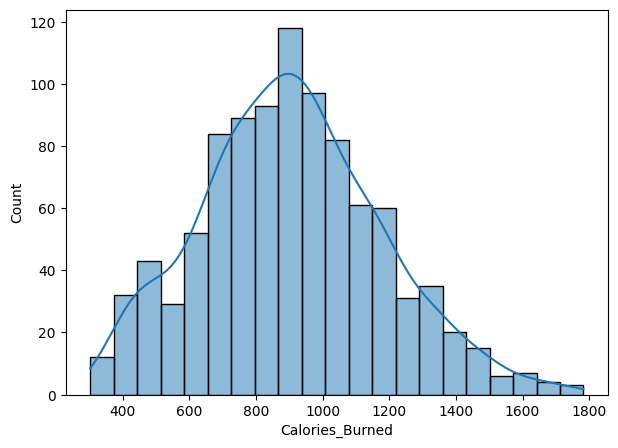

In [61]:
plt.figure(figsize=(7,5))
sns.histplot(df['Calories_Burned'],kde=True)

<Axes: >

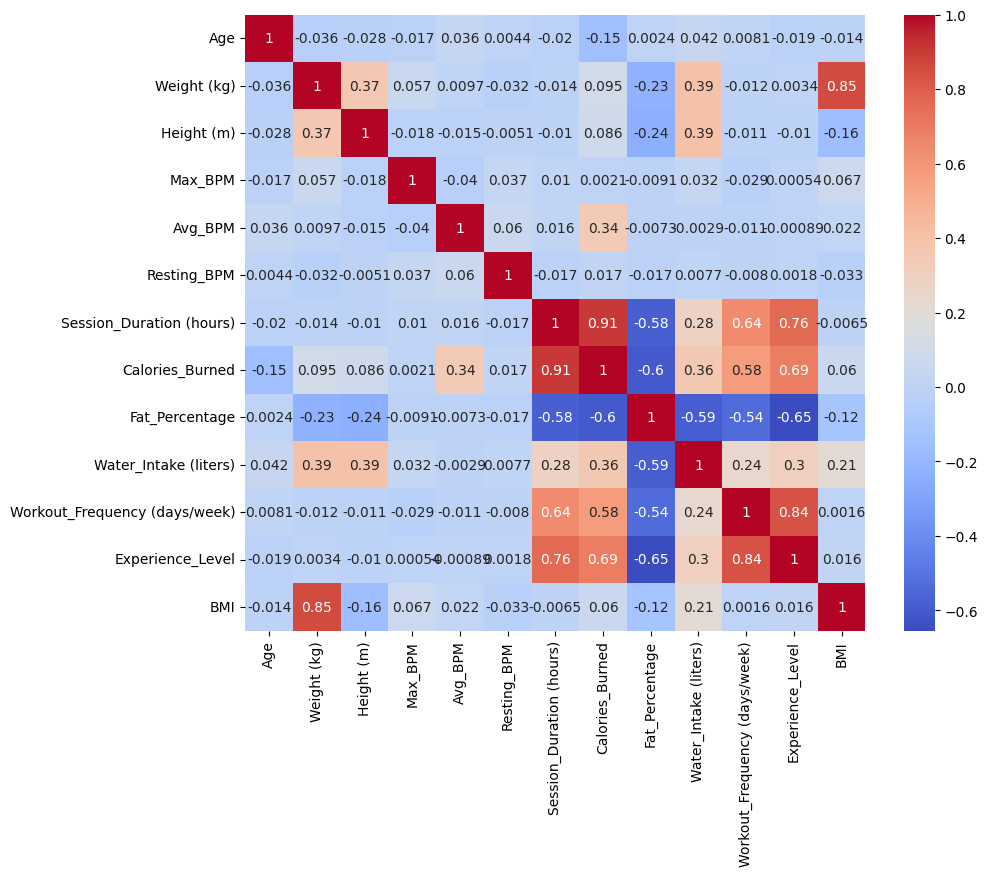

In [62]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

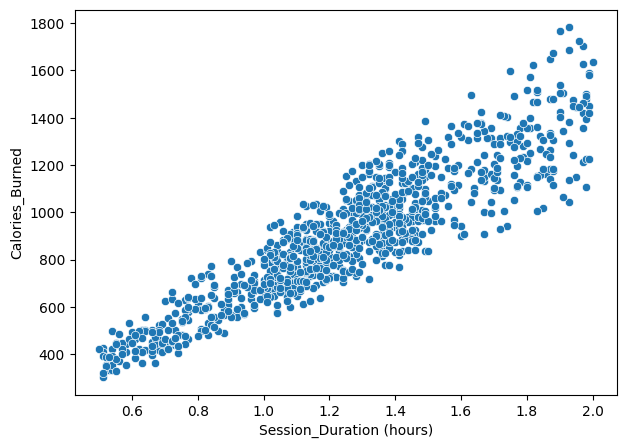

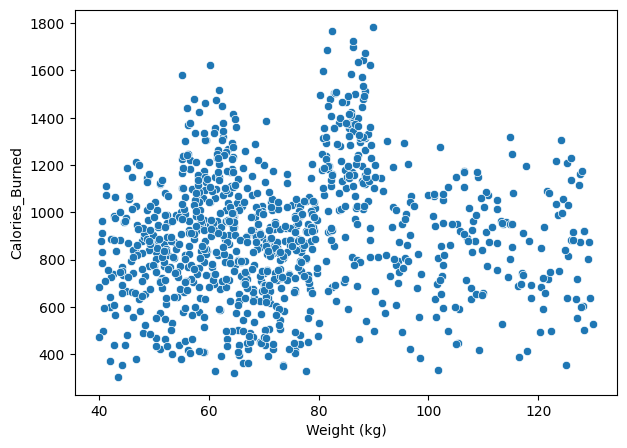

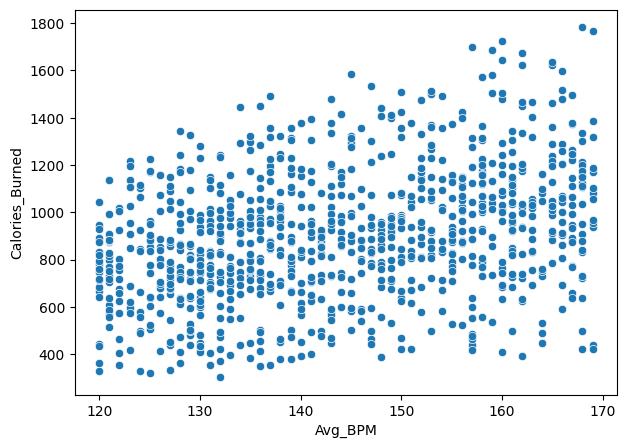

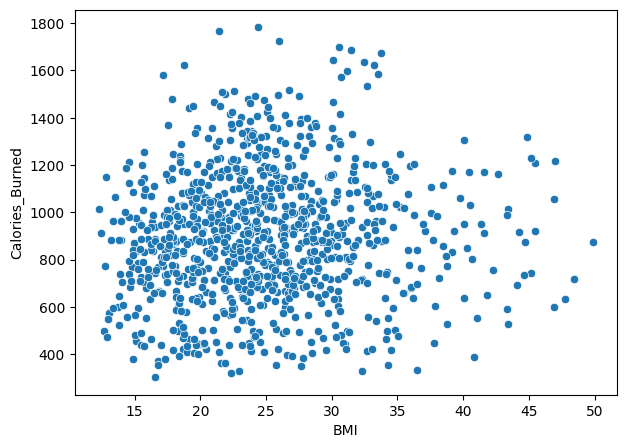

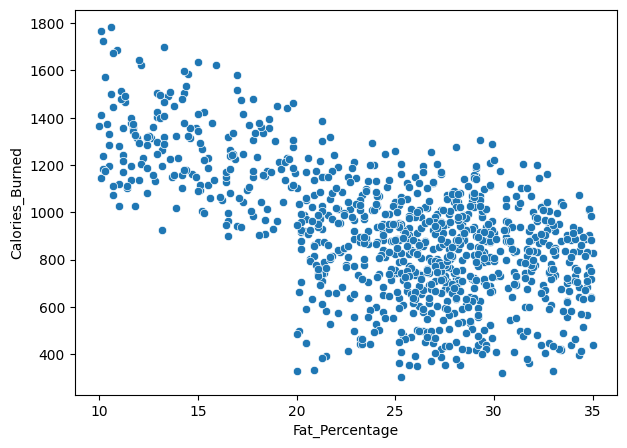

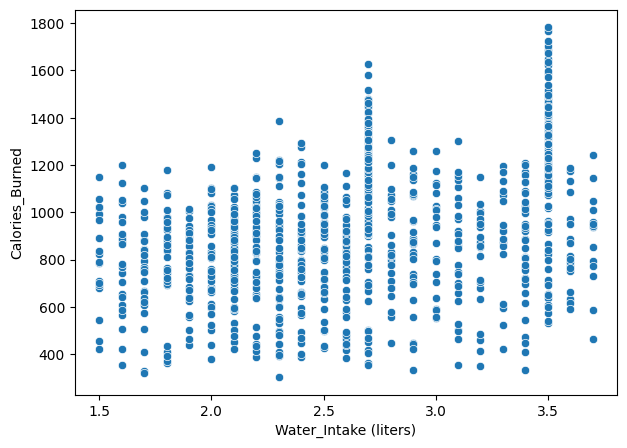

In [63]:
important = ['Session_Duration (hours)','Weight (kg)','Avg_BPM','BMI','Fat_Percentage','Water_Intake (liters)']
for col in important:
  plt.figure(figsize=(7,5))
  sns.scatterplot(x=df[col],y=df['Calories_Burned'])
  plt.show()

<Axes: xlabel='Gender', ylabel='Calories_Burned'>

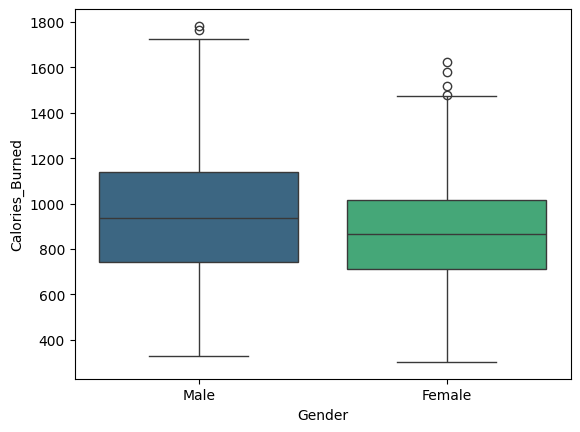

In [64]:
sns.boxplot(x='Gender',y='Calories_Burned',data=df,palette='viridis')

<Axes: xlabel='Workout_Type', ylabel='Calories_Burned'>

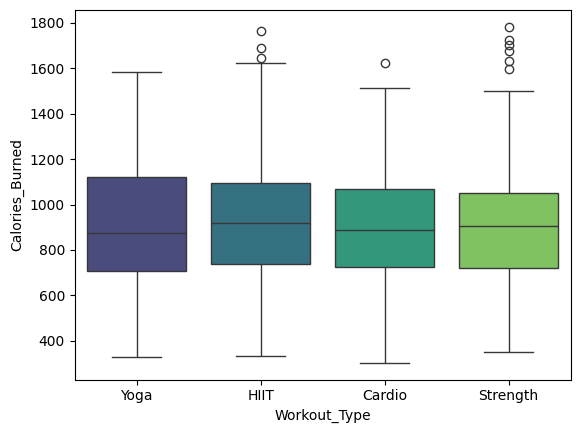

In [65]:
sns.boxplot(x='Workout_Type',y='Calories_Burned',data=df,palette='viridis')

<Axes: xlabel='Session_Duration (hours)', ylabel='Calories_Burned'>

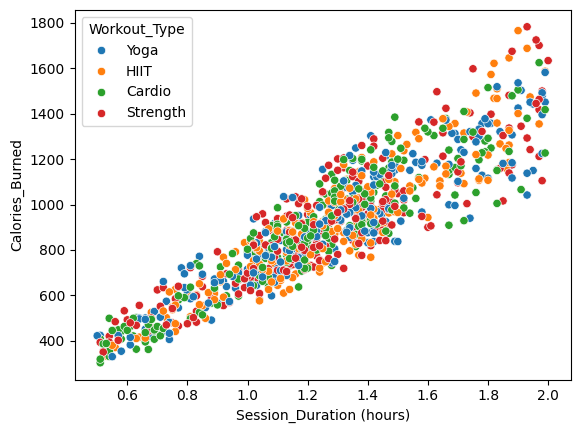

In [66]:
sns.scatterplot(
x='Session_Duration (hours)',
y='Calories_Burned',
hue='Workout_Type',
data=df
)

In [67]:
for col in num_col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR
  outliers = df[(df[col]<lower_bound)| (df[col]>upper_bound) ]
  print(f"{col}:{len(outliers)} outliers")

Age:0 outliers
Weight (kg):9 outliers
Height (m):0 outliers
Max_BPM:0 outliers
Avg_BPM:0 outliers
Resting_BPM:0 outliers
Session_Duration (hours):0 outliers
Calories_Burned:10 outliers
Fat_Percentage:0 outliers
Water_Intake (liters):0 outliers
Workout_Frequency (days/week):0 outliers
Experience_Level:0 outliers
BMI:25 outliers


### Feature Engineering

In [68]:
bins = [18,30,45,60]
labels = ['Young','Adult','Senior']
df['Age_group'] = pd.cut(df['Age'],bins = bins,labels=labels,include_lowest=True)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Age_group
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,Senior
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,Senior
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,Adult
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,Young
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,Adult


In [69]:
bins = [0,18.5,25,30,100]
labels = ['Underweight','Normal','Overweight','Obese']
df['Bmi_Category'] = pd.cut(df['BMI'],bins=bins,labels=labels)
df.sample(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Age_group,Bmi_Category
625,45,Female,58.2,1.70,168,160,53,0.95,684.0,Yoga,26.8,2.0,3,1,20.14,Adult,Normal
838,51,Male,102.6,1.77,193,130,59,1.21,779.0,HIIT,21.0,3.4,2,1,32.75,Senior,Obese
147,59,Male,50.3,1.95,188,167,55,1.07,885.0,Strength,24.4,3.4,3,1,13.23,Senior,Underweight
207,33,Female,65.3,1.71,172,135,74,1.18,796.0,HIIT,29.7,2.5,4,2,22.33,Adult,Normal
351,53,Female,56.9,1.59,199,164,65,1.49,1100.0,HIIT,29.5,2.0,3,2,22.51,Senior,Normal


In [70]:
corr = df.corr(numeric_only=True)['Calories_Burned']
corr = corr.sort_values(ascending=False)
print(corr)

Calories_Burned                  1.000000
Session_Duration (hours)         0.908140
Experience_Level                 0.694129
Workout_Frequency (days/week)    0.576150
Water_Intake (liters)            0.356931
Avg_BPM                          0.339659
Weight (kg)                      0.095443
Height (m)                       0.086348
BMI                              0.059761
Resting_BPM                      0.016518
Max_BPM                          0.002090
Age                             -0.154679
Fat_Percentage                  -0.597615
Name: Calories_Burned, dtype: float64


In [71]:
corr_low = corr[abs(corr)<0.10]
print(corr_low)

Weight (kg)    0.095443
Height (m)     0.086348
BMI            0.059761
Resting_BPM    0.016518
Max_BPM        0.002090
Name: Calories_Burned, dtype: float64


### Encoding

In [72]:
df = pd.get_dummies(df,columns=cat_col,drop_first=True)
df.sample(5)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Age_group,Bmi_Category,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
355,33,113.6,1.99,169,125,58,1.38,949.0,28.4,3.4,2,1,28.69,Adult,Overweight,True,False,True,False
744,30,77.9,1.77,166,130,62,1.41,916.0,27.9,2.6,4,2,24.87,Young,Normal,False,False,False,False
915,48,73.1,1.83,194,131,71,1.05,681.0,28.0,2.8,4,2,21.83,Senior,Normal,True,False,False,True
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,Adult,Underweight,True,False,True,False
21,38,71.9,1.77,197,142,72,1.12,875.0,25.7,3.1,2,1,22.95,Adult,Normal,True,False,False,False


### Feature Scaling (standardization)

In [74]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Calories_Burned',axis=1)
y = df['Calories_Burned']

# Identify categorical columns that might still exist in X (including 'category' dtype)
categorical_cols_in_X = X.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to these columns
X = pd.get_dummies(X, columns=categorical_cols_in_X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)


In [77]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [78]:
y_pred = model.predict(X_test)
y_pred

array([ 905.75, 1445.6 ,  889.54, 1080.1 , 1430.35, 1356.  ,  939.08,
        970.04, 1067.19, 1134.5 , 1286.71,  638.57,  805.84,  777.21,
        721.33,  735.31,  885.2 , 1141.84,  864.48,  532.51,  893.95,
        834.93,  841.81,  908.95,  516.81,  767.64,  935.8 ,  458.57,
        937.32, 1148.06,  669.39,  980.11,  666.97, 1249.87, 1271.79,
       1410.07,  635.1 ,  916.91,  632.  ,  414.82,  397.12,  719.4 ,
        427.43,  691.7 ,  930.29,  865.27,  760.87,  873.31,  818.63,
        877.52, 1038.23, 1116.6 , 1056.33, 1234.66,  768.8 , 1437.6 ,
        699.13,  436.3 ,  515.8 ,  729.63,  500.47, 1011.63, 1332.16,
       1132.49,  930.96,  872.14,  678.44, 1096.3 ,  975.18, 1173.51,
       1557.35,  965.34,  744.05, 1130.99, 1189.33,  777.35,  567.56,
        426.27, 1206.76, 1270.4 ,  770.46,  983.2 ,  900.16,  979.52,
       1066.15,  954.06, 1061.48,  359.62, 1153.77,  628.54, 1151.95,
        607.2 , 1348.51, 1274.48,  695.35,  734.24,  673.55,  717.53,
        868.28, 1616

In [81]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")

Mean Squared Error: 2261.152284102564
Mean Absolute Error: 36.318666666666665
R2 Score: 0.9728959953355938
